# Домашнее задание 4. Диффузия

В этом задании вам предстоит обучить модель Denoising Diffusion Probabilistic Model (DDPM) на наборе изображений лиц CelebA (размер 32×32). Решение должно включать обучающий ноутбук и сгенерированные изображения.

## Настройка окружения

In [3]:
# %pip install einops
# %pip install imageio

In [4]:
import sys
sys.path.append('../seminars/utils/')  # Добавляем путь к CelebADataset

import einops
import random
import imageio
import numpy as np
from argparse import ArgumentParser

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.transforms import Compose, ToTensor, Lambda, Resize
from torchvision.datasets.mnist import MNIST, FashionMNIST
from datasets.celeba import CelebADataset as CelebA

# Фиксируем seed для воспроизводимости
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

KeyboardInterrupt: 

## Визуализация данных

In [ ]:
def show_images(images, title=""):
    """Shows the provided images as sub-pictures in a square"""

    # Converting images to CPU numpy arrays
    if type(images) is torch.Tensor:
        images = images.detach().cpu().permute(0,2,3,1).numpy()

    # Defining number of rows and columns
    fig = plt.figure(figsize=(8, 8))
    rows = int(len(images) ** (1 / 2))
    cols = round(len(images) / rows)

    # Populating figure with sub-plots
    idx = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, idx + 1)

            if idx < len(images):
                plt.imshow((255*(images[idx]+1)/2).astype('uint8'))
                idx += 1
    fig.suptitle(title, fontsize=30)

    # Showing the figure
    plt.show()

In [ ]:
def show_first_batch(loader):
    for batch in loader:
        show_images(batch[:16], "Первый батч")
        break

## Загрузка данных (0 баллов)

В данном задании используется набор данных CelebA (32×32). **Важно**: нормализуйте данные в диапазоне `[-1, 1]`. 

In [ ]:
# Data Parameters
batch_size = 512
image_size = 32



from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),  # Изменение размера
    transforms.ToTensor(),  # Преобразование в тензор [0, 1]
    transforms.Lambda(lambda x: (x - 0.5) * 2)
])

# Кастомный датасет CelebA, возвращающий только изображения
class CelebaCustomDataset(CelebA):
    def __getitem__(self, idx):
        image, _ = super().__getitem__(idx)
        return image

dataset = CelebaCustomDataset(
    transform=transform,
    root_dir='../seminars/data/celeba',
)

loader = DataLoader(dataset, batch_size, shuffle=True, num_workers=8)

# Пример получения изображения
img = dataset[0]
print("Размер изображения:", img.shape)

Размер изображения: torch.Size([3, 32, 32])


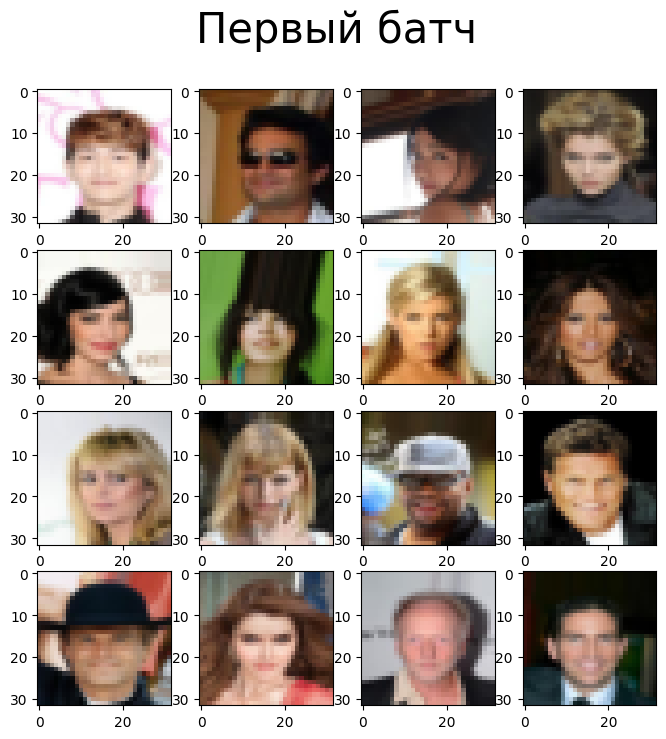

In [ ]:
mini_loader = DataLoader(dataset, 16, shuffle=True)
show_first_batch(mini_loader)

In [ ]:
# Set device
cuda = torch.cuda.is_available()
device = torch.device("cuda:3" if cuda else ("mps" if torch.backends.mps.is_available() else "cpu"))
torch.backends.cudnn.benchmark = cuda

print(f"Using device: {device}")

Using device: cuda:3


## Denoising Diffusion Probabilistic Model (DDPM)
### Краткое введение

*Диффузионная модель* — это обратимый марковский стохастический процесс, описывающий последовательное зашумление исходного изображения $\mathbf{x}_0$ вплоть до состояния чистого шума и обратное ему последовательное удаление шума. Прямой (forward) процесс добавления шума задаётся известным гауссовским законом $q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$, в то время как обратный (backward) процесс денойзинга $p(\mathbf{x}_{t-1} \vert \mathbf{x}_t)$ неизвестен и аппроксимируется нейросетью $p_\theta$:

![Иллюстрация процесса диффузии и денойзинга](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/DDPM.png)

*Прямой диффузионный процесс*, заданный распределением $q$, определяется следующими уравнениями:

$$
\begin{aligned}
\mathbf{x}_t &= \sqrt{\alpha_t}\,\mathbf{x}_{t-1} + \sqrt{1 - \alpha_t}\,\boldsymbol{\epsilon}_{t-1}, & \quad \boldsymbol{\epsilon}_{t-1}\sim \mathcal{N}(\mathbf{0}, \mathbf{I}),\\
&= \sqrt{\alpha_t\alpha_{t-1}}\,\mathbf{x}_{t-2} + \sqrt{1 - \alpha_t\alpha_{t-1}}\,\bar{\boldsymbol{\epsilon}}_{t-2}, & \quad \text{где } \bar{\boldsymbol{\epsilon}}_{t-2}\text{ — свёртка двух гауссиан,}\\
&\quad\quad\vdots\\
&= \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\,\boldsymbol{\epsilon}, & \quad \boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
\end{aligned}
$$

В общем виде распределение $q(\mathbf{x}_t\vert\mathbf{x}_0)$ принимает форму:
$$
q(\mathbf{x}_t \vert \mathbf{x}_0) = \mathcal{N}\left(\mathbf{x}_t; \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0, (1 - \bar{\alpha}_t)\mathbf{I}\right),
$$
где $\{\alpha_t\}$ и $\{\bar{\alpha}_t = \prod_{s=1}^t \alpha_s\}$ — заранее заданные по фиксированной сетке параметры.

*Обратный процесс денойзинга* $p_\theta$ — неизвестное распределение, моделируемое нейронной сетью, которое описывает переход от зашумленного состояния к менее зашумленному:
$$
p_\theta(\mathbf{x}_{t-1}\vert\mathbf{x}_t)=\mathcal{N}\left(\mathbf{x}_{t-1}; \mu_\theta(\mathbf{x}_t, t), \Sigma_\theta(\mathbf{x}_t, t)\right).
$$

Таким образом, модель предсказывает параметры $\mu_\theta$ и $\Sigma_\theta$ аналогично вариационному автоэнкодеру (VAE). Более того, обучение сети $p_\theta$ происходит посредством максимизации нижней вариационной оценки правдоподобия (ELBO), также подобно VAE, включая минимизацию KL-дивергенции между двумя гауссовскими распределениями.

После обучения обратного процесса, генерация изображения выполняется простым последовательным семплированием от шума к исходному изображению:

$$
\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \quad \mathbf{x}_{t-1}\sim p_\theta(\mathbf{x}_{t-1}\vert\mathbf{x}_t),\quad t=T, T-1, \dots, 1,
$$
где итоговый семпл $\mathbf{x}_0$ представляет собой денойзированное (восстановленное) изображение.

### Уточнение алгоритма обучения и генерации

Авторы оригинальной модели DDPM упрощают задачу, фиксируя дисперсию $\sigma_t^2$ обратного процесса денойзинга $p_\theta$ заранее известными константами, такими как:
$$
\sigma_t^2 = \beta_t \quad \text{или} \quad \sigma_t^2 = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_{t}} \beta_t.
$$

Тогда процессы денойзинга (обратный процесс) и зашумления (прямой процесс) приобретают простой вид:

$$
q(\mathbf{x}_{t-1}|\mathbf{x}_0, \mathbf{x}_t)=\mathcal{N}(\mathbf{x}_{t-1}; \boldsymbol{\mu}_t^q, \sigma_t^2 \mathbf{I}), \quad p_\theta(\mathbf{x}_{t-1}|\mathbf{x}_t)=\mathcal{N}(\mathbf{x}_{t-1}; \boldsymbol{\mu}_t^\theta, \sigma_t^2 \mathbf{I}),
$$
где математическое ожидание прямого процесса явно выражается как:

$$
\boldsymbol{\mu}^q_t = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \boldsymbol{\epsilon}_t \right).
$$

В соответствии с этим удобно представить и предсказание нейросети аналогично:

$$
\boldsymbol{\mu}_t^\theta = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t) \right).
$$

Тогда минимизация дивергенции KL между $q$ и $p_\theta$ сводится к минимизации среднеквадратичной ошибки (MSE):
$$
\text{KL}(q \parallel p_\theta) \sim \|\boldsymbol{\mu}_t^q - \boldsymbol{\mu}_t^\theta\|^2 \sim \|\boldsymbol{\epsilon}_t - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\|^2.
$$

Зашумленное изображение $\mathbf{x}_t$ можно эффективно получить напрямую из исходного изображения $\mathbf{x}_0$:
$$
\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\,\boldsymbol{\epsilon}_t, \quad \boldsymbol{\epsilon}_t \sim \mathcal{N}(\mathbf{0},\mathbf{I}).
$$

В результате обучение и генерация сводятся к кратким и эффективным алгоритмам, представленным ниже:

![Алгоритмы обучения (слева) и генерации (справа) DDPM](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/DDPM-algo.png)

*Примечание*: В качестве сети $\boldsymbol{\epsilon}_\theta$ используют архитектуру на основе Unet или специализированный под диффузию Efficient Unet.

*Дополнительная информация доступна в статье*: https://lilianweng.github.io/posts/2021-07-11-diffusion-models/

### Описание класса (2 балла)

In [ ]:
# DDPM class
class DDPM(nn.Module):
    def __init__(self, network, # Unet
                 n_steps=1000, # YOUR CODE HERE (число шагов диффузии)
                 min_beta=0.0001, # YOUR CODE HERE
                 max_beta=0.02, # YOUR CODE HERE
                 device=None,
                 image_chw=(3, image_size, image_size)):
        super().__init__()
        self.n_steps = n_steps
        self.device = device
        self.image_chw = image_chw
        self.network = network.to(device) # Ваш backbone (Unet), реализуете его ниже
        self.betas = torch.linspace(min_beta, max_beta, n_steps).to(device) # Задайте beta по любой понравившейся сетке, как на семинаре
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)

    def forward(self, x0, t, eta=None):
        # Прямой проход диффузии (детерменированный марковский процесс)
        # :param x0 - исходная картинка (тензор формы [B,C,H,W])
        # :param t - шаг зашумления (тензор формы [B,1])
        # :param eta - \epsilon_t - добавочный шум на шаге зашумления t (тензор формы [B,C,H,W])
        
        # YOUR CODE HERE
        if eta is None:
            eta =  eta = torch.randn_like(x0).to(self.device) # если шум не определен - инициализируйте его гауссом N(0,1) сами


        batch_size = x0.shape[0]
        alpha_bar_t = self.alpha_bars[t].view(batch_size, 1, 1, 1)
        
        noised_x = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * eta

        return noised_x

    def backward(self, x, t):
        # Обратный процесс. Здесь вам предстоит восстановить добавочный шум eta из зашумлённой картинки x на шаге t нейросетью
        eta_pred = self.network(x, t)
        return eta_pred

### Visualizing forward and backward (2 балла)

In [ ]:
def show_forward(ddpm, loader, device):
    for batch in loader:
        imgs = batch

        show_images(imgs, "Original images")

        for percent in [0.1, 0.5, 0.75, 1]: # Шаг зашумления (в процентах от максимального)
            # YOUR CODE HERE. Зашумите ваши картинки прямым проходом DDPM
            
            noised_images = ddpm(imgs.to(device),
                     [int(percent * ddpm.n_steps) - 1 for _ in range(len(imgs))])
            
            show_images(
                noised_images,
                f"DDPM Noisy images {int(percent * 100)}%"
            )
        break

In [ ]:
def generate_new_images(ddpm, n_samples=16, device=None, frames_per_gif=100,
                        gif_name="sampling.gif", c=3, h=image_size, w=image_size):
    """Given a DDPM model, a number of samples to be generated and a device, returns some newly generated samples"""
    frame_idxs = np.linspace(0, ddpm.n_steps, frames_per_gif).astype(np.uint)
    frames = []

    with torch.no_grad():
        if device is None:
            device = ddpm.device

        # Starting from random noise
        x = torch.randn(n_samples, c, h, w).to(device) # Начинаем генерить картинки с гауссовского шума N(0,1) ([n_samples, c, h, w])

        for idx, t in enumerate(reversed(range(ddpm.n_steps))): # Денойзим наши картинки для каждого шага, начиная с последнего
            # Estimating noise to be removed
            time_tensor = torch.ones(n_samples, 1, device=device).long() * t # [n_samples, 1].long()
            eta_theta = ddpm.backward(x, time_tensor) #  Предсказываем добавочный шум нейросетью

            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]

            # Partially denoising the image
            x = x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta) # Вычитаем добавочный шум из картинки

            if t > 0:
                z = torch.randn(n_samples, c, h, w).to(device)

                sigma_t = torch.sqrt(ddpm.betas[t]) # определите сигму по любому из предлагаемых DDPM способов

                x = x + sigma_t * z

            # Adding frames to the GIF
            if idx in frame_idxs or t == 0:
                normalized = x.clone()
                # YOUR CODE HERE (нормируем картинку обратно в интервал [0,255])
                normalized = (normalized * 0.5 + 0.5) * 255
                normalized = normalized.clamp(0, 255).byte()

                # Reshaping batch (n, c, h, w) to be a (as much as it gets) square frame
                frame = einops.rearrange(normalized, "(b1 b2) c h w -> (b1 h) (b2 w) c", b1=int(n_samples ** 0.5))
                frame = frame.cpu().numpy().astype(np.uint8)

                # Rendering frame
                frames.append(frame)

    # Storing the gif
    with imageio.get_writer(gif_name, mode="I") as writer:
        for idx, frame in enumerate(frames):
            writer.append_data(frame)
            if idx == len(frames) - 1:
                for _ in range(frames_per_gif // 3):
                    writer.append_data(frames[-1])
    return x

## Архитектура UNet ($\boldsymbol{\epsilon}^\theta$) (3 балла)

Как ранее упоминалось, для реализации функции $\boldsymbol{\epsilon}^\theta$ подходит любая нейросеть на основе архитектуры UNet. Такая сеть принимает на вход зашумлённое изображение и возвращает предсказанный шум $\boldsymbol{\epsilon}_t$, имеющий ту же размерность. Однако возникает одно усложнение: в исходной (ванильной) архитектуре UNet отсутствует возможность принимать дополнительный аргумент — шаг времени (момент зашумления) $t$.

Для решения этой проблемы существует множество подходов, например, адаптивная нормализация экземпляров (AdaIN), как в архитектуре StyleGAN, добавление времени отдельным каналом и другие методы.

На практике в модели DDPM обычно используется подход, основанный на позиционном кодировании времени (positional encoding), аналогичном кодированию из модели Transformer. Полученное таким образом кодирование времени $t$ прибавляется непосредственно к входному изображению $\mathbf{x}$. Более того, иногда вместе с временным кодированием к изображению добавляются ещё и текстовые эмбеддинги, предварительно сжатые до подходящей размерности с помощью дополнительного линейного слоя.

В рамках текущего задания работа с текстовыми эмбеддингами не предусмотрена, а временной аргумент $t$ будет интегрирован именно через описанный выше подход с использованием позиционного кодирования.

In [ ]:
def sinusoidal_embedding(n, d):
    # n - размерность исходных данных (в нашем случае число моментов времени)
    # d - выходная размерность
    embedding = torch.zeros(n, d)
    wk = torch.tensor([1 / 10_000 ** (2 * j / d) for j in range(d)]) # коэффициенты для d гармоник
    wk = wk.reshape((1, d))
    t = torch.arange(n).reshape((n, 1))
    # заполните половину из d компонент синунами sin(wk*t), оставшуюся косинусами cos(wk*t), где wk - коэффициенты гармоник

    embedding[:,::2] = torch.sin(t * wk[:,::2])
    embedding[:,1::2] = torch.cos(t * wk[:,::2])

    return embedding

In [ ]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


In [ ]:
class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

In [ ]:
import torch.nn.functional as F


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=False):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels , in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)


    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

In [ ]:
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
class MyBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, kernel_size=3, stride=1, padding=1, activation=None, normalize=True):
        super(MyBlock, self).__init__()
        self.ln = nn.LayerNorm(shape)
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, stride, padding)
        self.activation = nn.SiLU() if activation is None else activation
        self.normalize = normalize

    def forward(self, x):
        out = self.ln(x) if self.normalize else x
        out = self.conv1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.activation(out)
        return out

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet32(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=100, in_ch=1, out_ch=1):
        super(UNet32, self).__init__()

        # Sinusoidal embedding
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)

        # First half
        self.te1 = self._make_te(time_emb_dim, in_ch)
        self.b1 = nn.Sequential(
            MyBlock((in_ch, 32, 32), in_ch, 10),
            MyBlock((10, 32, 32), 10, 10),
            MyBlock((10, 32, 32), 10, 10)
        )
        self.down1 = nn.Conv2d(10, 10, 4, 2, 1)  # 32x32 -> 16x16

        self.te2 = self._make_te(time_emb_dim, 10)
        self.b2 = nn.Sequential(
            MyBlock((10, 16, 16), 10, 20),
            MyBlock((20, 16, 16), 20, 20),
            MyBlock((20, 16, 16), 20, 20)
        )
        self.down2 = nn.Conv2d(20, 20, 4, 2, 1)  # 16x16 -> 8x8

        self.te3 = self._make_te(time_emb_dim, 20)
        self.b3 = nn.Sequential(
            MyBlock((20, 8, 8), 20, 40),
            MyBlock((40, 8, 8), 40, 40),
            MyBlock((40, 8, 8), 40, 40)
        )
        self.down3 = nn.Conv2d(40, 40, 4, 2, 1)  # 8x8 -> 4x4

        # Bottleneck
        self.te_mid = self._make_te(time_emb_dim, 40)
        self.b_mid = nn.Sequential(
            MyBlock((40, 4, 4), 40, 20),
            MyBlock((20, 4, 4), 20, 20),
            MyBlock((20, 4, 4), 20, 40)
        )

        # Second half with skip connections
        self.up1 = nn.ConvTranspose2d(40, 40, 4, 2, 1)  # 4x4 -> 8x8

        self.te4 = self._make_te(time_emb_dim, 80)  # 40 + 40 from skip connection
        self.b4 = nn.Sequential(
            MyBlock((80, 8, 8), 80, 40),
            MyBlock((40, 8, 8), 40, 20),
            MyBlock((20, 8, 8), 20, 20)
        )

        self.up2 = nn.ConvTranspose2d(20, 20, 4, 2, 1)  # 8x8 -> 16x16
        self.te5 = self._make_te(time_emb_dim, 40)  # 20 + 20 from skip connection
        self.b5 = nn.Sequential(
            MyBlock((40, 16, 16), 40, 20),
            MyBlock((20, 16, 16), 20, 10),
            MyBlock((10, 16, 16), 10, 10)
        )

        self.up3 = nn.ConvTranspose2d(10, 10, 4, 2, 1)  # 16x16 -> 32x32
        self.te_out = self._make_te(time_emb_dim, 20)  # 10 + 10 from skip connection
        self.b_out = nn.Sequential(
            MyBlock((20, 32, 32), 20, 10),
            MyBlock((10, 32, 32), 10, 10),
            MyBlock((10, 32, 32), 10, 10, normalize=False)
        )

        self.conv_out = nn.Conv2d(10, out_ch, 3, 1, 1)

    def forward(self, x, t):
        t = self.time_embed(t)
        n = len(x)
        
        # Encoder path
        out1 = self.b1(x + self.te1(t).reshape(n, -1, 1, 1))  # (N, 10, 32, 32)
        out2 = self.b2(self.down1(out1) + self.te2(t).reshape(n, -1, 1, 1))  # (N, 20, 16, 16)
        out3 = self.b3(self.down2(out2) + self.te3(t).reshape(n, -1, 1, 1))  # (N, 40, 8, 8)

        # Bottleneck
        out_mid = self.b_mid(self.down3(out3) + self.te_mid(t).reshape(n, -1, 1, 1))  # (N, 40, 4, 4)

        # Decoder path with skip connections
        out4 = torch.cat((out3, self.up1(out_mid)), dim=1)  # (N, 80, 8, 8)
        out4 = self.b4(out4 + self.te4(t).reshape(n, -1, 1, 1))  # (N, 20, 8, 8)

        out5 = torch.cat((out2, self.up2(out4)), dim=1)  # (N, 40, 16, 16)
        out5 = self.b5(out5 + self.te5(t).reshape(n, -1, 1, 1))  # (N, 10, 16, 16)

        out = torch.cat((out1, self.up3(out5)), dim=1)  # (N, 20, 32, 32)
        out = self.b_out(out + self.te_out(t).reshape(n, -1, 1, 1))  # (N, 10, 32, 32)

        out = self.conv_out(out)  # (N, out_ch, 32, 32)

        return out

    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out)
        )


In [ ]:
class ImprovedUNet32(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=256, in_ch=1, out_ch=1):
        super(ImprovedUNet32, self).__init__()

        # Увеличенная размерность эмбеддинга времени
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)

        # Первая половина (энкодер) - увеличенное число каналов
        self.te1 = self._make_te(time_emb_dim, in_ch)
        self.b1 = nn.Sequential(
            MyBlock((in_ch, 32, 32), in_ch, 64),
            nn.Dropout(0.1),
            MyBlock((64, 32, 32), 64, 64),
            MyBlock((64, 32, 32), 64, 64),
            MyBlock((64, 32, 32), 64, 64)
        )
        self.down1 = nn.Conv2d(64, 64, 4, 2, 1)  # 32x32 -> 16x16

        self.te2 = self._make_te(time_emb_dim, 64)
        self.b2 = nn.Sequential(
            MyBlock((64, 16, 16), 64, 128),
            nn.Dropout(0.1),
            MyBlock((128, 16, 16), 128, 128),
            MyBlock((128, 16, 16), 128, 128),
            MyBlock((128, 16, 16), 128, 128)
        )
        self.down2 = nn.Conv2d(128, 128, 4, 2, 1)  # 16x16 -> 8x8

        self.te3 = self._make_te(time_emb_dim, 128)
        self.b3 = nn.Sequential(
            MyBlock((128, 8, 8), 128, 256),
            nn.Dropout(0.1),
            MyBlock((256, 8, 8), 256, 256),
            MyBlock((256, 8, 8), 256, 256),
            MyBlock((256, 8, 8), 256, 256)
        )
        self.down3 = nn.Conv2d(256, 256, 4, 2, 1)  # 8x8 -> 4x4

        # Боттлнек с увеличенным числом каналов
        self.te_mid = self._make_te(time_emb_dim, 256)
        self.b_mid = nn.Sequential(
            MyBlock((256, 4, 4), 256, 512),
            nn.Dropout(0.1),
            MyBlock((512, 4, 4), 512, 512),
            MyBlock((512, 4, 4), 512, 256)
        )

        # Вторая половина (декодер) со skip-connections
        self.up1 = nn.ConvTranspose2d(256, 256, 4, 2, 1)  # 4x4 -> 8x8

        self.te4 = self._make_te(time_emb_dim, 512)  # 256 + 256 из skip connection
        self.b4 = nn.Sequential(
            MyBlock((512, 8, 8), 512, 256),
            nn.Dropout(0.1),
            MyBlock((256, 8, 8), 256, 256),
            MyBlock((256, 8, 8), 256, 128),
            MyBlock((128, 8, 8), 128, 128)
        )

        self.up2 = nn.ConvTranspose2d(128, 128, 4, 2, 1)  # 8x8 -> 16x16
        self.te5 = self._make_te(time_emb_dim, 256)  # 128 + 128 из skip connection
        self.b5 = nn.Sequential(
            MyBlock((256, 16, 16), 256, 128),
            nn.Dropout(0.1),
            MyBlock((128, 16, 16), 128, 128),
            MyBlock((128, 16, 16), 128, 64),
            MyBlock((64, 16, 16), 64, 64)
        )

        self.up3 = nn.ConvTranspose2d(64, 64, 4, 2, 1)  # 16x16 -> 32x32
        self.te_out = self._make_te(time_emb_dim, 128)  # 64 + 64 из skip connection
        self.b_out = nn.Sequential(
            MyBlock((128, 32, 32), 128, 64),
            nn.Dropout(0.1),
            MyBlock((64, 32, 32), 64, 64),
            MyBlock((64, 32, 32), 64, 32),
            MyBlock((32, 32, 32), 32, 32, normalize=False)
        )

        # Выходной слой с большей глубиной фильтра для улучшения деталей
        self.conv_out = nn.Sequential(
            nn.Conv2d(32, 32, 3, 1, 1),
            nn.SiLU(),
            nn.Conv2d(32, out_ch, 3, 1, 1)
        )
        
        # Применение правильной инициализации весов
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, t):
        t = self.time_embed(t)
        n = len(x)
        
        # Encoder path
        out1 = self.b1(x + self.te1(t).reshape(n, -1, 1, 1))  # (N, 64, 32, 32)
        out2 = self.b2(self.down1(out1) + self.te2(t).reshape(n, -1, 1, 1))  # (N, 128, 16, 16)
        out3 = self.b3(self.down2(out2) + self.te3(t).reshape(n, -1, 1, 1))  # (N, 256, 8, 8)

        # Bottleneck
        out_mid = self.b_mid(self.down3(out3) + self.te_mid(t).reshape(n, -1, 1, 1))  # (N, 256, 4, 4)

        # Decoder path with skip connections
        out4 = torch.cat((out3, self.up1(out_mid)), dim=1)  # (N, 512, 8, 8)
        out4 = self.b4(out4 + self.te4(t).reshape(n, -1, 1, 1))  # (N, 128, 8, 8)

        out5 = torch.cat((out2, self.up2(out4)), dim=1)  # (N, 256, 16, 16)
        out5 = self.b5(out5 + self.te5(t).reshape(n, -1, 1, 1))  # (N, 64, 16, 16)

        out = torch.cat((out1, self.up3(out5)), dim=1)  # (N, 128, 32, 32)
        out = self.b_out(out + self.te_out(t).reshape(n, -1, 1, 1))  # (N, 32, 32, 32)

        out = self.conv_out(out)  # (N, out_ch, 32, 32)

        return out

    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out),
            nn.SiLU()  # Добавлен дополнительный слой активации
        )

In [ ]:
dataset[0].unsqueeze(0).shape

torch.Size([1, 3, 32, 32])

In [ ]:
# Create the model
model = ImprovedUNet32(in_ch=3, out_ch=3)

# Test input
x = torch.randn(4, 3, 32, 32)  # Batch of 4 RGB images of size 32x32
t = torch.randint(0, 1000, (4, 1))  # Random timesteps for each image in the batch

# Forward pass
output = model(x, t)

# Check output shape
print("Output shape:", output.shape)

Output shape: torch.Size([4, 3, 32, 32])


In [ ]:
# Defining model
assert image_size == 32
n_steps, min_beta, max_beta = 1000, 0.0001, 0.02


def get_ddpm_model():
    return DDPM(ImprovedUNet32(in_ch=3, out_ch=3, n_steps=n_steps), n_steps=n_steps, min_beta=min_beta, max_beta=max_beta, device=device)

ddpm = get_ddpm_model()

In [ ]:
sum([p.numel() for p in ddpm.parameters()])

26277330

## Optional visualizations

In [ ]:
# Optionally, load a pre-trained model that will be further trained
# ddpm.load_state_dict(torch.load(store_path, map_location=device))

In [ ]:
# Optionally, show the diffusion (forward) process


# show_forward(ddpm, loader, device)

In [ ]:
# Optionally, show the denoising (backward) process
# generated = generate_new_images(ddpm, gif_name="before_training.gif")
# show_images(generated, "Images generated before training")

## Обучение (1 балл)
![](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/DDPM-algo.png)

In [ ]:
from torch.optim.lr_scheduler import StepLR


def training_loop(ddpm, loader, n_epochs, optim, device, display=False, store_path="ddpm_model.pt"):
    mse = nn.MSELoss()
    best_loss = float("inf")
    n_steps = ddpm.n_steps


    scheduler = StepLR(optim, step_size=5, gamma=0.1)

    for epoch in tqdm(range(n_epochs), desc=f"Training progress", colour="#00ff00"):
        epoch_loss = 0.0
        for step, batch in enumerate(tqdm(loader, leave=False, desc=f"Epoch {epoch + 1}/{n_epochs}", colour="#005500")):
            x0 = batch.to(device)
            n = len(x0)
            
            eta = torch.randn_like(x0, device=device) # инициализируем добавочный шум
            t = torch.randint(0, n_steps, (x0.shape[0],), device=device)

            noisy_imgs = ddpm(x0, t, eta)   # получаем зашумленное изображение для шага t 

            # Getting model estimation of noise based on the images and the time-step
            eta_theta = ddpm.backward(noisy_imgs, t.reshape(n, -1)) # восстанавливаем добавочный шум

            loss = mse(eta_theta, eta) # учимся его восстанавливать нейросетью
            optim.zero_grad()
            loss.backward()
            optim.step()

            epoch_loss += loss.item() * len(x0) / len(loader.dataset)
        scheduler.step()

        # Display images generated at this epoch
        if display:
            show_images(generate_new_images(ddpm, device=device), f"Images generated at epoch {epoch + 1}")

        log_string = f"Loss at epoch {epoch + 1}: {epoch_loss:.3f}"

        # Storing the model
        if best_loss > epoch_loss:
            best_loss = epoch_loss
            torch.save(ddpm.state_dict(), store_path)
            log_string += " --> Best model ever (stored)"

        print(log_string)

In [ ]:
store_path = "celeba_ddpm.ckpt"

In [28]:
# Training
n_epochs = 40
lr = 0.0003

training_loop(ddpm, loader, n_epochs, optim=Adam(ddpm.parameters(), lr), device=device, store_path=store_path, display=False)

Training progress:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/40:   0%|          | 0/396 [00:00<?, ?it/s]

Loss at epoch 1: 1.074 --> Best model ever (stored)


Epoch 2/40:   0%|          | 0/396 [00:00<?, ?it/s]

Loss at epoch 2: 0.852 --> Best model ever (stored)


...

Loss at epoch 38: 0.139


Epoch 39/40:   0%|          | 0/396 [00:00<?, ?it/s]

Loss at epoch 39: 0.139


Epoch 40/40:   0%|          | 0/396 [00:00<?, ?it/s]

Loss at epoch 40: 0.139


## Генерёжка (2 балла за хорошие картинки)

In [ ]:
# Loading the trained model
best_model = get_ddpm_model()
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()
print("Model loaded")

In [ ]:
print("Generating new images")
generated = generate_new_images(
        best_model,
        n_samples=63,
        device=device,
        gif_name="celeba.gif"
    )
show_images(generated, "Final result")

## Visualizing the diffusion

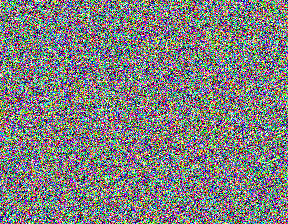

In [31]:
from IPython.display import Image

Image(open('celeba.gif','rb').read())

что то не так с нормализацией